In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA

In [ ]:
PROCESSED = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/'

In [ ]:
# W5 — CITY-LEVEL FEATURE MATRIX
#  One row per city

business   = pd.read_parquet(PROCESSED + 'business_clean.parquet')
bridge     = pd.read_parquet(PROCESSED + 'business_categories.parquet')
checkin    = pd.read_parquet(PROCESSED + 'checkin_clean.parquet')
interact   = pd.read_parquet(PROCESSED + 'review_interactions.parquet')

print(f'Unique cities on dataset: {business["city"].nunique():,}')

Unique cities on dataset: 1,416


In [ ]:
business.describe()

,latitude,longitude,stars,review_count,is_open,n_categories,hours__open_days,hours__has_weekend,hours__open_monday,hours__open_tuesday,hours__open_wednesday,hours__open_thursday,hours__open_friday,hours__open_saturday,hours__open_sunday
count,150346.000000,150346.000000,150346.000000,150346.000000,150346.00000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000
mean,36.671150,-89.357339,3.596724,44.866561,0.79615,4.447022,5.327811,0.740938,0.761404,0.802356,0.823241,0.832732,0.831409,0.736767,0.539901
std,5.872759,14.918502,0.974421,121.120136,0.40286,2.233734,2.445235,0.438121,0.426227,0.398224,0.381466,0.373216,0.374392,0.440389,0.498407
min,27.555127,-120.095137,1.000000,5.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.187293,-90.357810,3.000000,8.000000,1.00000,3.000000,5.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
50%,38.777413,-86.121179,3.500000,15.000000,1.00000,4.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,39.954036,-75.421542,4.500000,37.000000,1.00000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,53.679197,-73.200457,5.000000,7568.000000,1.00000,36.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 58 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   business_id                       150346 non-null  object  
 1   name                              150346 non-null  object  
 2   city                              150346 non-null  object  
 3   state                             150346 non-null  object  
 4   latitude                          150346 non-null  float64 
 5   longitude                         150346 non-null  float64 
 6   stars                             150346 non-null  float64 
 7   review_count                      150346 non-null  int64   
 8   is_open                           150346 non-null  int64   
 9   categories_list                   150346 non-null  object  
 10  primary_category                  150243 non-null  object  
 11  n_categories                      15034

In [ ]:
# basic metrics of businesses per city
# it captures a city's general profile on quality(stars) and activity(reviews)

bus_per_city = business.groupby('city').agg(
    n_businesses      = ('business_id', 'count'),        # size of city
    avg_stars         = ('stars', 'mean'),               # average stars
    median_stars      = ('stars', 'median'),             # median stars
    std_stars         = ('stars', 'std'),                # quantifies the amount of variation of stars around their mean
    total_reviews     = ('review_count', 'sum'),         # total reviews (activity)
    avg_reviews_per_biz = ('review_count', 'mean'),      # avg of total reviews
    pct_open          = ('is_open', 'mean'),             # % of open businesses
    avg_n_categories  = ('n_categories', 'mean'),        # avg categories of businesses
).reset_index()

print(f'Businesses per city info shape: {bus_per_city.shape}')
print(bus_per_city.head(3))

Businesses per city info shape: (1416, 9)
          city  n_businesses  avg_stars  median_stars  std_stars  \
0  AB Edmonton             1        4.5           4.5        NaN   
1       AMBLER             1        3.0           3.0        NaN   
2      ARDMORE             1        3.0           3.0        NaN   

   total_reviews  avg_reviews_per_biz  pct_open  avg_n_categories  
0              6                  6.0       1.0               2.0  
1              9                  9.0       1.0               4.0  
2              8                  8.0       1.0               4.0  


## attributes per city
business_clean (columns attr__ boolean)

it captures the city "type" ( turism, family, nightlife, etc.)
from attributes of the businesses

In [ ]:
attr_city = [c for c in business.columns if c.startswith('attr__')
             and business[c].dtype == 'boolean']

# Converts boolean to int to do means and completes null values with false(0)
biz_attrs = business[['city'] + attr_city].copy()
for c in attr_city:
    biz_attrs[c] = biz_attrs[c].astype('object').map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).fillna(0).astype(float)

In [ ]:
biz_attrs.head()

,city,attr__ByAppointmentOnly,attr__BusinessAcceptsCreditCards,attr__BikeParking,attr__RestaurantsTakeOut,attr__RestaurantsDelivery,attr__Caters,attr__BusinessParking__garage,attr__BusinessParking__street,attr__BusinessParking__validated,...,attr__Ambience__classy,attr__Ambience__trendy,attr__Ambience__upscale,attr__Ambience__casual,attr__GoodForMeal__dessert,attr__GoodForMeal__latenight,attr__GoodForMeal__lunch,attr__GoodForMeal__dinner,attr__GoodForMeal__brunch,attr__GoodForMeal__breakfast
0,Santa Barbara,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Affton,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Tucson,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Philadelphia,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Green Lane,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# we verify there's not a null value
biz_attrs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   city                              150346 non-null  object 
 1   attr__ByAppointmentOnly           150346 non-null  float64
 2   attr__BusinessAcceptsCreditCards  150346 non-null  float64
 3   attr__BikeParking                 150346 non-null  float64
 4   attr__RestaurantsTakeOut          150346 non-null  float64
 5   attr__RestaurantsDelivery         150346 non-null  float64
 6   attr__Caters                      150346 non-null  float64
 7   attr__BusinessParking__garage     150346 non-null  float64
 8   attr__BusinessParking__street     150346 non-null  float64
 9   attr__BusinessParking__validated  150346 non-null  float64
 10  attr__BusinessParking__lot        150346 non-null  float64
 11  attr__BusinessParking__valet      150346 non-null  f

In [ ]:
# mean per city: ex."40% of businesses on this city have a romantic ambience"
at_per_city = biz_attrs.groupby('city')[attr_city].mean().reset_index()

# rename for clarity
at_per_city.columns = ['city'] + ['city_pct_' + c.replace('attr__', '')
                               for c in attr_city]

print(f'Attributes per city shape: {at_per_city.shape}')

Attributes per city shape: (1416, 33)


In [ ]:
# we add categoricals now
# PriceRange (ordinal)
price_map = {'1': 1, '2': 2, '3': 3, '4': 4}
business['price_num'] = business['attr__RestaurantsPriceRange2'].astype(str).map(price_map)

# NoiseLevel (ordinal)
noise_map = {'quiet': 1, 'average': 2, 'loud': 3, 'very_loud': 4}
business['noise_num'] = business['attr__NoiseLevel'].astype(str).map(noise_map)

# fill nans
business['price_num'] = business['price_num'].fillna(business['price_num'].median())
business['noise_num'] = business['noise_num'].fillna(business['noise_num'].median())

# WiFi, Alcohol, Attire → % of every business per city
wifi_dummies    = pd.get_dummies(business['attr__WiFi'],             prefix='wifi')
alcohol_dummies = pd.get_dummies(business['attr__Alcohol'],          prefix='alcohol')
attire_dummies  = pd.get_dummies(business['attr__RestaurantsAttire'], prefix='attire')

In [ ]:
wifi_dummies.shape

(150346, 3)

In [ ]:
biz_extra = pd.concat([
    business[['city', 'price_num', 'noise_num']],
    wifi_dummies,
    alcohol_dummies,
    attire_dummies
], axis=1)

# aggregates per city
at_per_city_extra = biz_extra.groupby('city').mean().reset_index()
# mean() on dummies gives % of businesses with that attribute
# mean() on price_num, noise_num gives ordinal mean

print(f'Attributes per city shape: {at_per_city_extra.shape}')

Attributes per city shape: (1416, 12)


In [ ]:
# combine at_per_city with at_per_city_extra
at_per_city = at_per_city.merge(at_per_city_extra, on='city', how='left')

In [ ]:
at_per_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 1416 non-null   object 
 1   city_pct_ByAppointmentOnly           1416 non-null   float64
 2   city_pct_BusinessAcceptsCreditCards  1416 non-null   float64
 3   city_pct_BikeParking                 1416 non-null   float64
 4   city_pct_RestaurantsTakeOut          1416 non-null   float64
 5   city_pct_RestaurantsDelivery         1416 non-null   float64
 6   city_pct_Caters                      1416 non-null   float64
 7   city_pct_BusinessParking__garage     1416 non-null   float64
 8   city_pct_BusinessParking__street     1416 non-null   float64
 9   city_pct_BusinessParking__validated  1416 non-null   float64
 10  city_pct_BusinessParking__lot        1416 non-null   float64
 11  city_pct_BusinessParking__vale

In [ ]:
new_column_names = {}
for col in at_per_city.columns:
    if col not in ['city'] and not col.startswith('city_pct_') and col not in['price_num'] and col not in ['noise_num']:
        new_column_names[col] = 'city_pct_' + col

at_per_city = at_per_city.rename(columns=new_column_names)

print(f'Attributes per city shape after renaming: {at_per_city.shape}')

Attributes per city shape after renaming: (1416, 44)


In [ ]:
at_per_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 1416 non-null   object 
 1   city_pct_ByAppointmentOnly           1416 non-null   float64
 2   city_pct_BusinessAcceptsCreditCards  1416 non-null   float64
 3   city_pct_BikeParking                 1416 non-null   float64
 4   city_pct_RestaurantsTakeOut          1416 non-null   float64
 5   city_pct_RestaurantsDelivery         1416 non-null   float64
 6   city_pct_Caters                      1416 non-null   float64
 7   city_pct_BusinessParking__garage     1416 non-null   float64
 8   city_pct_BusinessParking__street     1416 non-null   float64
 9   city_pct_BusinessParking__validated  1416 non-null   float64
 10  city_pct_BusinessParking__lot        1416 non-null   float64
 11  city_pct_BusinessParking__vale

we verify its well constructed by showing an ex. with Philadelphia city

In [ ]:
biz_attrs['city'].value_counts()

,count
city,
Philadelphia,14569
Tucson,9250
Tampa,9050
Indianapolis,7540
Nashville,6971
...,...
Wesley Chapel FL,1
Monchanin,1
Lower Southampton,1


In [ ]:
Phil_city = at_per_city[at_per_city['city']=='Philadelphia']

Philadelphia is more of a family centered(good for kids) city rather than a romantic one

In [ ]:
Phil_city['city_pct_Ambience__romantic']

,city_pct_Ambience__romantic
866,0.007825


In [ ]:
Phil_city['city_pct_GoodForKids']

,city_pct_GoodForKids
866,0.288695


/tmp/ipykernel_9179/2298015878.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average Percentage', y='Attribute', data=plot_data, palette='viridis')


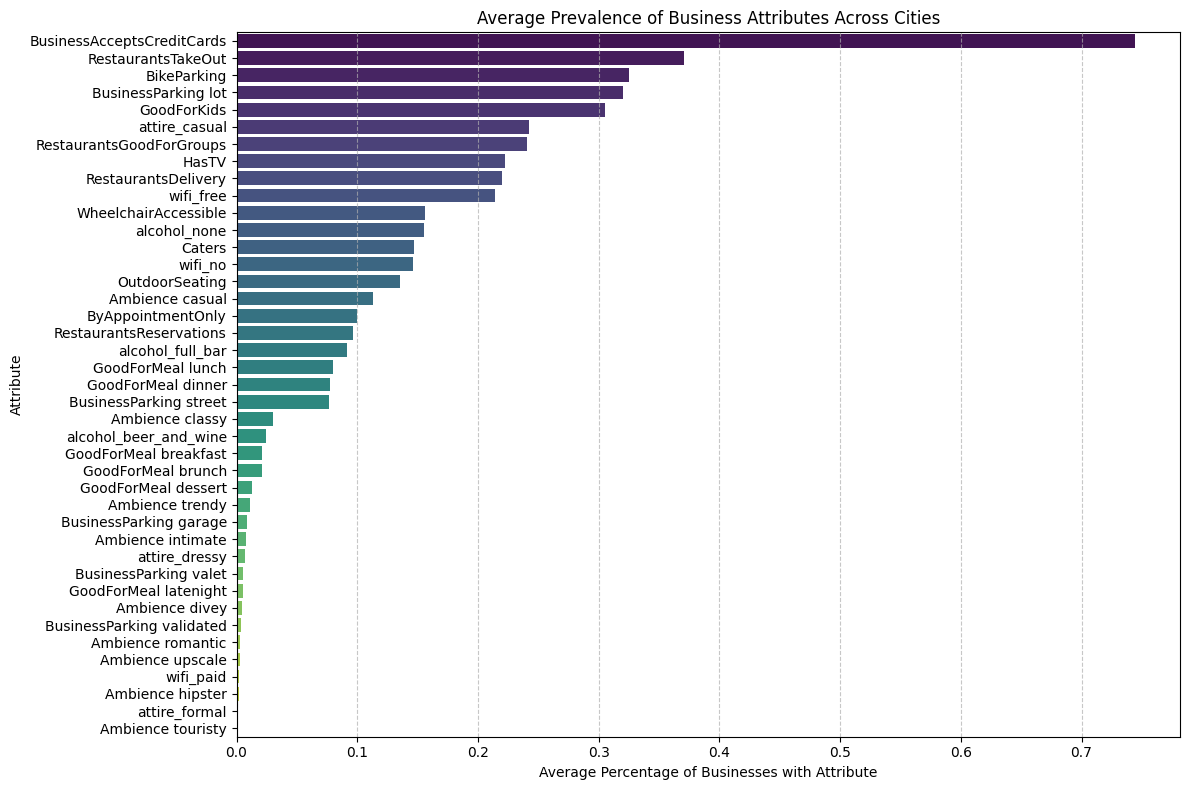

In [ ]:
# attribute columns (excluding 'city')
attribute_cols = [col for col in at_per_city.columns if col.startswith('city_pct_')]

# Calculate mean of each attribute across all cities
mean_attributes = at_per_city[attribute_cols].mean().sort_values(ascending=False)

plot_data = pd.DataFrame({
    'Attribute': mean_attributes.index.str.replace('city_pct_', '').str.replace('__', ' ', regex=False),
    'Average Percentage': mean_attributes.values
})

plt.figure(figsize=(12, 8))
sns.barplot(x='Average Percentage', y='Attribute', data=plot_data, palette='viridis')
plt.title('Average Prevalence of Business Attributes Across Cities')
plt.xlabel('Average Percentage of Businesses with Attribute')
plt.ylabel('Attribute')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

With the graph we can conclude that most businesses accept credit cards (aprx 75%)

In [ ]:
credit_card_acceptance = at_per_city.sort_values(by='city_pct_BusinessAcceptsCreditCards', ascending=False).head(590)
credit_card_acceptance.tail(35)

In [ ]:
# Sort DataFrame by 'city_pct_BusinessAcceptsCreditCards' in descending order
credit_card_acceptance = at_per_city.sort_values(by='city_pct_BusinessAcceptsCreditCards', ascending=False).head(590)
credit_card_acceptance = credit_card_acceptance.tail(35)
fig = px.bar(
    credit_card_acceptance,
    x='city',
    y='city_pct_BusinessAcceptsCreditCards',
    title='Percentage of Businesses Accepting Credit Cards (555-590)',
    labels={
        'city': 'City',
        'city_pct_BusinessAcceptsCreditCards': 'Percentage of Businesses Accepting Credit Cards'
    },
    hover_data={'city': True, 'city_pct_BusinessAcceptsCreditCards': ':.2%'}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(xaxis_title='City', yaxis_title='Percentage Accepting Credit Cards')
fig.show()

##Distribution of categories per city (top 30)

In [ ]:
bridgelisted = bridge['category'].value_counts()

In [ ]:
bridgelisted.shape

(1311,)

In [ ]:
# we pick 101 because it covers 70% of categories for all businesses
bl_percentage = bridgelisted.cumsum() / bridgelisted.sum()
cut_70 = np.argmax(bl_percentage >= 0.70)
print("Top 70%:", cut_70)

Top 70%: 101


Why 101 and not all 1311? Because rare categories add noise and make the matrix huge. Top 101 covers 70% of categories for all businesses

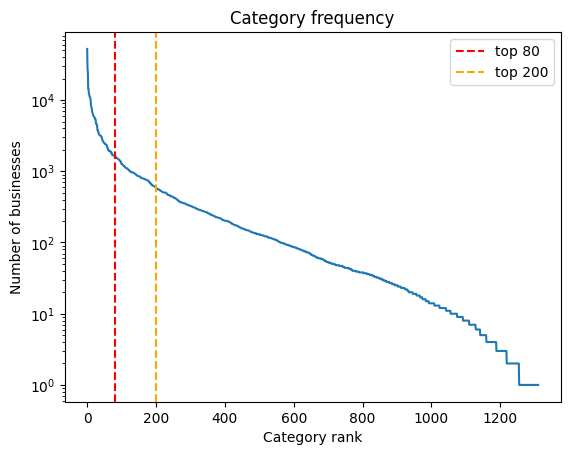

In [ ]:
# is a long-tail case
plt.plot(range(len(bridgelisted)), bridgelisted.values)
plt.axvline(80,  color='red',    linestyle='--', label='top 80')
plt.axvline(200, color='orange', linestyle='--', label='top 200')
plt.xlabel('Category rank')
plt.ylabel('Number of businesses')
plt.title('Category frequency')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
#  business_categories bridge
#  "personality" of a city is defined by what types of businesses its got
TOP_CATS = 101  # we dont add more to prevent noise

top_cats = bridge['category'].value_counts().head(TOP_CATS).index.tolist()
bridge_top = bridge[bridge['category'].isin(top_cats)].copy()

In [ ]:
bridge_top.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466798 entries, 0 to 668588
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   business_id  466798 non-null  object
 1   category     466798 non-null  object
dtypes: object(2)
memory usage: 10.7+ MB


In [ ]:
# quantity of businesses per category
bridge_city = bridge_top.merge(
    business[['business_id', 'city']], on='business_id', how='left'
)

In [ ]:
# Pivot: city × category = % of businesses belonging to a specific category within each city.
cat_counts = bridge_city.groupby(['city', 'category']).size().reset_index(name='count')
city_totals = business.groupby('city')['business_id'].count().reset_index(name='total')
cat_counts  = cat_counts.merge(city_totals, on='city')
cat_counts['pct'] = cat_counts['count'] / cat_counts['total']

city_category = cat_counts.pivot_table(
    index='city', columns='category', values='pct', fill_value=0
).reset_index()
city_category.columns.name = None
city_category.columns = ['city'] + ['cat_pct__' + c.replace(' ', '_')
                               for c in city_category.columns[1:]]

print(f'City X Category shape: {city_category.shape}')

City X Category shape: (1414, 102)


In [ ]:
# PERSONALITY GROUPS — reemplaza los 101 cat_pct__ por
#  14 columnas semánticas agregadas
PERSONALITY_GROUPS = {
    'personality__food_dining': [
        'Restaurants', 'Food', 'Pizza', 'Italian', 'Mexican',
        'Chinese', 'American (Traditional)', 'American (New)',
        'Sandwiches', 'Burgers', 'Sushi Bars', 'Thai', 'Japanese',
        'Indian', 'Mediterranean', 'Vietnamese', 'Greek',
        'Fast Food', 'Breakfast & Brunch', 'Desserts', 'Bakeries',
        'Ice Cream & Frozen Yogurt', 'Coffee & Tea', 'Juice Bars & Smoothies'
    ],
    'personality__nightlife_social': [
        'Bars', 'Nightlife', 'Cocktail Bars', 'Sports Bars',
        'Dance Clubs', 'Lounges', 'Karaoke', 'Wine Bars', 'Pubs'
    ],
    'personality__beauty_wellness': [
        'Hair Salons', 'Nail Salons', 'Beauty & Spas', 'Waxing',
        'Hair Removal', 'Skin Care', 'Massage', 'Day Spas',
        'Eyelash Service', 'Makeup Artists', 'Barbers', 'Tanning'
    ],
    'personality__health_medical': [
        'Health & Medical', 'Doctors', 'Dentists', 'Hospitals',
        'Optometrists', 'Physical Therapy', 'Medical Centers',
        'Chiropractors', 'Urgent Care'
    ],
    'personality__shopping_retail': [
        'Shopping', 'Fashion', 'Grocery', 'Drugstores',
        'Department Stores', 'Jewelry', 'Sporting Goods',
        'Electronics', 'Furniture Stores'
    ],
    'personality__fitness_outdoors': [
        'Fitness & Instruction', 'Gyms', 'Yoga', 'Parks',
        'Hiking', 'Active Life', 'Swimming Pools', 'Tennis',
        'Golf', 'Sports Clubs'
    ],
    'personality__religious_community': [
        'Religious Organizations', 'Churches',
        'Community Service/Non-Profit', 'Synagogues',
        'Mosques', 'Hindu Temples'
    ],
    'personality__professional_services': [
        'Financial Services', 'Banks & Credit Unions', 'Insurance',
        'Real Estate', 'Lawyers', 'Accountants', 'Marketing',
        'IT Services & Computer Repair'
    ],
    'personality__home_services': [
        'Home Services', 'Contractors', 'Plumbing', 'Electricians',
        'Landscaping', 'Movers', 'Interior Design', 'Roofing',
        'Heating & Air Conditioning/HVAC'
    ],
    'personality__arts_culture': [
        'Arts & Entertainment', 'Museums', 'Art Galleries',
        'Music Venues', 'Performing Arts', 'Comedy Clubs',
        'Cinema', 'Zoos', 'Aquariums'
    ],
    'personality__automotive': [
        'Automotive', 'Auto Repair', 'Car Dealers',
        'Oil Change Stations', 'Car Wash', 'Tires',
        'Gas Stations', 'Parking'
    ],
    'personality__education': [
        'Education', 'Tutoring Centers', 'Preschools',
        'Specialty Schools', 'Libraries'
    ],
    'personality__hotels_travel': [
        'Hotels & Travel', 'Hotels', 'Bed & Breakfast', 'Hostels',
        'Travel Services', 'Vacation Rentals', 'Tours',
        'Airport Shuttles'
    ],
    'personality__pets': [
        'Pets', 'Veterinarians', 'Pet Stores', 'Pet Groomers',
        'Dog Parks', 'Pet Training'
    ],
}

In [ ]:
all_grouped_cats = []
for cats in PERSONALITY_GROUPS.values():
    all_grouped_cats.extend(cats)

covered = bridge[bridge['category'].isin(all_grouped_cats)]
print(f"Bridge rows covered: {len(covered):,} de {len(bridge):,}")
print(f"Businesses covered: {len(covered)/len(bridge):.1%}")

Bridge rows covered: 408,252 de 668,592
Businesses covered: 61.1%


In [ ]:
all_categories_in_bridge = set(bridge['category'].unique())
total_covered = set()
for group_name, cats in PERSONALITY_GROUPS.items():
    found     = [c for c in cats if c in all_categories_in_bridge]
    not_found = [c for c in cats if c not in all_categories_in_bridge]
    total_covered.update(found)
    print(f"\n{group_name}:")
    print(f"  found ({len(found)}): {found}")
    if not_found:
        print(f"  not found: {not_found}")

print(f"\nTotal categories covered: {len(total_covered)} of {len(all_categories_in_bridge)}")


personality__food_dining:
  found (24): ['Restaurants', 'Food', 'Pizza', 'Italian', 'Mexican', 'Chinese', 'American (Traditional)', 'American (New)', 'Sandwiches', 'Burgers', 'Sushi Bars', 'Thai', 'Japanese', 'Indian', 'Mediterranean', 'Vietnamese', 'Greek', 'Fast Food', 'Breakfast & Brunch', 'Desserts', 'Bakeries', 'Ice Cream & Frozen Yogurt', 'Coffee & Tea', 'Juice Bars & Smoothies']

personality__nightlife_social:
  found (9): ['Bars', 'Nightlife', 'Cocktail Bars', 'Sports Bars', 'Dance Clubs', 'Lounges', 'Karaoke', 'Wine Bars', 'Pubs']

personality__beauty_wellness:
  found (12): ['Hair Salons', 'Nail Salons', 'Beauty & Spas', 'Waxing', 'Hair Removal', 'Skin Care', 'Massage', 'Day Spas', 'Eyelash Service', 'Makeup Artists', 'Barbers', 'Tanning']

personality__health_medical:
  found (9): ['Health & Medical', 'Doctors', 'Dentists', 'Hospitals', 'Optometrists', 'Physical Therapy', 'Medical Centers', 'Chiropractors', 'Urgent Care']

personality__shopping_retail:
  found (9): ['Shoppi

unrepresented categories are the ones that appear less in the dataset and are too specific to define a city's personality.


In [ ]:
list(bridge['category'].unique())

['Doctors',
 'Traditional Chinese Medicine',
 'Naturopathic/Holistic',
 'Acupuncture',
 'Health & Medical',
 'Nutritionists',
 'Shipping Centers',
 'Local Services',
 'Notaries',
 'Mailbox Centers',
 'Printing Services',
 'Department Stores',
 'Shopping',
 'Fashion',
 'Home & Garden',
 'Electronics',
 'Furniture Stores',
 'Restaurants',
 'Food',
 'Bubble Tea',
 'Coffee & Tea',
 'Bakeries',
 'Brewpubs',
 'Breweries',
 'Burgers',
 'Fast Food',
 'Sandwiches',
 'Ice Cream & Frozen Yogurt',
 'Sporting Goods',
 'Shoe Stores',
 'Sports Wear',
 'Accessories',
 'Synagogues',
 'Religious Organizations',
 'Pubs',
 'Italian',
 'Bars',
 'American (Traditional)',
 'Nightlife',
 'Greek',
 'Vietnamese',
 'Food Trucks',
 'Diners',
 'Breakfast & Brunch',
 'General Dentistry',
 'Dentists',
 'Cosmetic Dentists',
 'Delis',
 'Sushi Bars',
 'Japanese',
 'Automotive',
 'Auto Parts & Supplies',
 'Auto Customization',
 'Vape Shops',
 'Tobacco Shops',
 'Personal Shopping',
 'Vitamins & Supplements',
 'Car Rental

In [ ]:
# build personality features per city using bridge_city

# bridge_city (business_id + category + city)
# city_totals
personality_features = city_totals[['city']].copy()

for group_name, cats in PERSONALITY_GROUPS.items():
    # Unique businesses on this city that belong to the group
    group_biz = bridge_city[bridge_city['category'].isin(cats)]\
                .groupby('city')['business_id']\
                .nunique()\
                .reset_index()
    group_biz.columns = ['city', 'count']

    temp = city_totals.merge(group_biz, on='city', how='left')
    temp['count'] = temp['count'].fillna(0)
    personality_features[group_name] = (temp['count'] / temp['total']).values

print(f"Personality features shape: {personality_features.shape}")
print(f"\nMean per group (% mean on cities):")
for col in personality_features.columns[1:]:
    print(f"  {col.replace('personality__',''):<30} {personality_features[col].mean():.3f}")

Personality features shape: (1416, 15)

Mean per group (% mean on cities):
  food_dining                    0.456
  nightlife_social               0.059
  beauty_wellness                0.081
  health_medical                 0.059
  shopping_retail                0.155
  fitness_outdoors               0.059
  religious_community            0.000
  professional_services          0.019
  home_services                  0.108
  arts_culture                   0.034
  automotive                     0.089
  education                      0.012
  hotels_travel                  0.048
  pets                           0.028


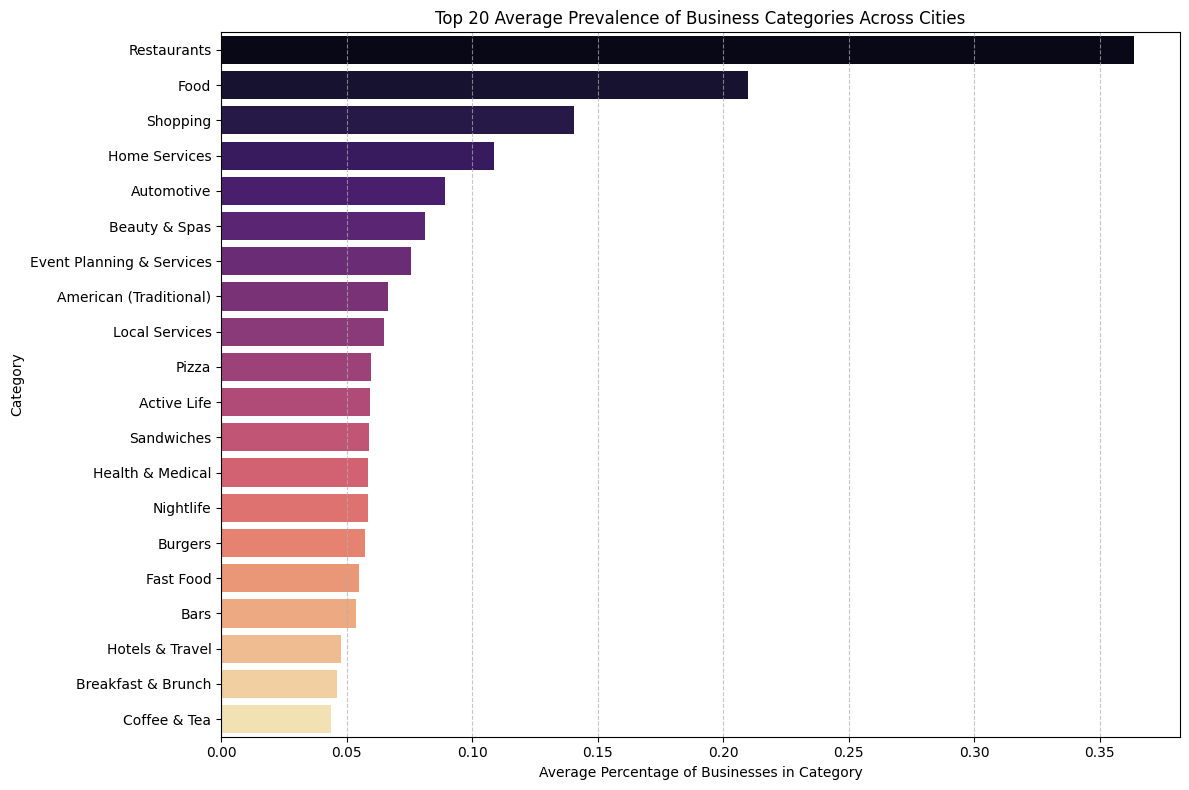

In [ ]:
# category columns (excluding 'city')
category_cols = [col for col in city_category.columns if col.startswith('cat_pct__')]

# Calculate mean percentage for each category across all cities and get the top 20
mean_category_percentages = city_category[category_cols].mean().sort_values(ascending=False).head(20)

plot_data_cats = pd.DataFrame({
    'Category': mean_category_percentages.index.str.replace('cat_pct__', '').str.replace('_', ' '),
    'Average Percentage': mean_category_percentages.values
})

plt.figure(figsize=(12, 8))
sns.barplot(x='Average Percentage', y='Category', data=plot_data_cats, palette='magma', hue='Category', legend=False)
plt.title('Top 20 Average Prevalence of Business Categories Across Cities')
plt.xlabel('Average Percentage of Businesses in Category')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
colms = []
for col in city_category:
  colms.append(col)

print(colms)

['city', 'cat_pct__Accessories', 'cat_pct__Active_Life', 'cat_pct__American_(New)', 'cat_pct__American_(Traditional)', 'cat_pct__Apartments', 'cat_pct__Arts_&_Crafts', 'cat_pct__Arts_&_Entertainment', 'cat_pct__Asian_Fusion', 'cat_pct__Auto_Parts_&_Supplies', 'cat_pct__Auto_Repair', 'cat_pct__Automotive', 'cat_pct__Bakeries', 'cat_pct__Barbeque', 'cat_pct__Barbers', 'cat_pct__Bars', 'cat_pct__Beauty_&_Spas', 'cat_pct__Beer', 'cat_pct__Breakfast_&_Brunch', 'cat_pct__Burgers', 'cat_pct__Cafes', 'cat_pct__Car_Dealers', 'cat_pct__Caterers', 'cat_pct__Chicken_Wings', 'cat_pct__Chinese', 'cat_pct__Cocktail_Bars', 'cat_pct__Coffee_&_Tea', 'cat_pct__Contractors', 'cat_pct__Convenience_Stores', 'cat_pct__Cosmetic_Dentists', 'cat_pct__Cosmetics_&_Beauty_Supply', 'cat_pct__Day_Spas', 'cat_pct__Delis', 'cat_pct__Dentists', 'cat_pct__Department_Stores', 'cat_pct__Desserts', 'cat_pct__Diners', 'cat_pct__Doctors', 'cat_pct__Drugstores', 'cat_pct__Education', 'cat_pct__Electronics', 'cat_pct__Event_Pl

In [ ]:
city_category.head(5)

,city,cat_pct__Accessories,cat_pct__Active_Life,cat_pct__American_(New),cat_pct__American_(Traditional),cat_pct__Apartments,cat_pct__Arts_&_Crafts,cat_pct__Arts_&_Entertainment,cat_pct__Asian_Fusion,cat_pct__Auto_Parts_&_Supplies,...,cat_pct__Sports_Bars,cat_pct__Steakhouses,cat_pct__Sushi_Bars,cat_pct__Tires,cat_pct__Trainers,cat_pct__Venues_&_Event_Spaces,cat_pct__Veterinarians,cat_pct__Waxing,cat_pct__Wine_&_Spirits,cat_pct__Women's_Clothing
0,AB Edmonton,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,AMBLER,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,ARDMORE,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3,AVON,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4,Abington,0.005917,0.029586,0.035503,0.059172,0.0,0.011834,0.011834,0.023669,0.005917,...,0.005917,0.011834,0.029586,0.023669,0.0,0.011834,0.005917,0.023669,0.017751,0.011834


In [ ]:
personality_features.head(5)

,city,personality__food_dining,personality__nightlife_social,personality__beauty_wellness,personality__health_medical,personality__shopping_retail,personality__fitness_outdoors,personality__religious_community,personality__professional_services,personality__home_services,personality__arts_culture,personality__automotive,personality__education,personality__hotels_travel,personality__pets
0,AB Edmonton,0.00000,0.000000,1.000000,0.00000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,AMBLER,0.00000,0.000000,1.000000,0.00000,1.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ARDMORE,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
3,AVON,1.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Abington,0.39645,0.023669,0.130178,0.16568,0.16568,0.029586,0.0,0.029586,0.076923,0.011834,0.059172,0.017751,0.005917,0.017751


In [ ]:
city_category['cat_pct__Beauty_&_Spas'].head(5)

,cat_pct__Beauty_&_Spas
0,1.000000
1,1.000000
2,0.000000
3,0.000000
4,0.130178


In [ ]:
personality_features.shape

(1416, 15)

In [ ]:
city_category.shape

(1414, 102)

## Reviews per city

In [ ]:
# review_interactions + business (to map city)
#  captures real users' behaviour

# map business_id → city
biz_city = business[['business_id', 'city']].copy()
interact_city = interact.merge(biz_city, on='business_id', how='left')

In [ ]:
ic = interact_city.value_counts()
ic.head(3)

,,,,count
user_id,business_id,stars,city,
a0DnfD31lNdiBTY2-YBBFA,C6YaSrMAzy3jJqinlFVudw,5,New Orleans,35
I6x-ZBHeCNlMnmtfUVf5lg,PUfhLM-MkjQYZw4ldnJqzQ,5,Reno,32
xWmYN57XXZbg0LOK8WbbFQ,gfLsBY-xsNE9-ktiTvTvGA,5,Tucson,30


In [ ]:
bus_city = interact_city.groupby('city').agg(
    city_avg_rating   = ('stars', 'mean'),
    city_rating_std   = ('stars', 'std'),
    city_n_reviews    = ('stars', 'count'),
    city_n_users      = ('user_id', 'nunique'),
    pct_5stars        = ('stars', lambda x: (x == 5).mean()),  # % perfect ratings
    pct_1stars        = ('stars', lambda x: (x == 1).mean()),  # % negative ratings
).reset_index()

bus_city['city_rating_std'] = bus_city['city_rating_std'].fillna(0)

print(f'Reviews per city shape: {bus_city.shape}')

Reviews per city shape: (1416, 7)


In [ ]:
bus_city.head(2)

,city,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars
0,AB Edmonton,4.333333,1.632993,6,6,0.833333,0.166667
1,AMBLER,3.000000,1.825742,10,9,0.400000,0.300000


In [ ]:
bus_city[bus_city['city']=='Philadelphia']

,city,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars
866,Philadelphia,3.785673,1.388208,967552,279857,0.430728,0.123244


In [ ]:
# plot top 10 cities with highest pct_5stars
top_5stars = bus_city.sort_values(by='pct_5stars', ascending=False).head(10)
fig = px.bar(
    top_5stars,
    x='city',
    y='pct_5stars',
    title='Top 10 Cities with Highest Percentage of Perfect Ratings',
    labels={
        'city': 'City',
        'pct_5stars': 'Percentage of Perfect Ratings'
    },
    hover_data={'city': True, 'pct_5stars': ':.2%'}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color sequence
)
fig.update_layout(xaxis_title='City', yaxis_title='Percentage of Perfect Ratings')
fig.show()

## Checkins per city

In [ ]:
# checkin_clean + business
# real popularity doesnt depend of N ratings

checkin_city = checkin.merge(biz_city, on='business_id', how='left')

Checks_in = checkin_city.groupby('city').agg(
    total_checkins    = ('n_checkins', 'sum'),   # total visits
    avg_checkins_biz  = ('n_checkins', 'mean'),
    max_checkins_biz  = ('n_checkins', 'max'),   # most visited business
).reset_index()

print(f'Checkins per city shape: {Checks_in.shape}')

Checkins per city shape: (1301, 4)


In [ ]:
# Top 5 cities with more checkins
top_checkins = Checks_in.sort_values(by='total_checkins', ascending=False).head(5)
fig = px.bar(
    top_checkins,
    x='city',
    y='total_checkins',
    title='Top 5 Cities with Highest Total Checkins',
    labels={
        'city': 'City',
        'total_checkins': 'Total Checkins'
    },
    hover_data={'city': True}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color sequence
)
fig.update_layout(xaxis_title='City', yaxis_title='Total checkins')
fig.show()

In [ ]:
city_category.head()

,city,cat_pct__Accessories,cat_pct__Active_Life,cat_pct__American_(New),cat_pct__American_(Traditional),cat_pct__Apartments,cat_pct__Arts_&_Crafts,cat_pct__Arts_&_Entertainment,cat_pct__Asian_Fusion,cat_pct__Auto_Parts_&_Supplies,...,cat_pct__Sports_Bars,cat_pct__Steakhouses,cat_pct__Sushi_Bars,cat_pct__Tires,cat_pct__Trainers,cat_pct__Venues_&_Event_Spaces,cat_pct__Veterinarians,cat_pct__Waxing,cat_pct__Wine_&_Spirits,cat_pct__Women's_Clothing
0,AB Edmonton,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,AMBLER,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,ARDMORE,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3,AVON,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4,Abington,0.005917,0.029586,0.035503,0.059172,0.0,0.011834,0.011834,0.023669,0.005917,...,0.005917,0.011834,0.029586,0.023669,0.0,0.011834,0.005917,0.023669,0.017751,0.011834


In [ ]:
# merge
city_features = bus_per_city.copy()
city_features = city_features.merge(at_per_city, on='city', how='left')
city_features = city_features.merge(personality_features, on='city', how='left')
#city_features = city_features.merge(city_category, on='city', how='left')
city_features = city_features.merge(bus_city, on='city', how='left')
city_features = city_features.merge(Checks_in, on='city', how='left')

In [ ]:
city_features.isna().sum()

,0
city,0
n_businesses,0
avg_stars,0
median_stars,0
std_stars,590
...,...
pct_5stars,0
pct_1stars,0
total_checkins,115
avg_checkins_biz,115


we had 164 rows before with cities' categories not grouped by personalities now we have 75

In [ ]:
city_features = city_features.fillna(0)

In [ ]:
city_features.isna().sum().sum()

np.int64(0)

In [ ]:
city_features.head(2)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,personality__pets,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
0,AB Edmonton,1,4.5,4.5,0.0,6,6.0,1.0,2.0,0.0,...,0.0,4.333333,1.632993,6,6,0.833333,0.166667,5.0,5.0,5.0
1,AMBLER,1,3.0,3.0,0.0,9,9.0,1.0,4.0,1.0,...,0.0,3.000000,1.825742,10,9,0.400000,0.300000,2.0,2.0,2.0


In [ ]:
print(f'\nCITY FEATURE MATRIX')
print(f'Cities: {city_features.shape[0]:,}')
print(f'Features: {city_features.shape[1] - 1}')
print(f'NaN:      {city_features.isna().sum().sum()}')
print(f'Memoria:  {city_features.memory_usage(deep=True).sum() / 1e6:.1f} MB')

city_features.to_parquet(PROCESSED + 'city_features_new.parquet', index=False)
print('\nGuardado: city_features_new.parquet')


CITY FEATURE MATRIX
Cities: 1,416
Features: 74
NaN:      0
Memoria:  0.9 MB

Guardado: city_features_new.parquet


## PCA

In [ ]:
city_features = pd.read_parquet(PROCESSED + 'city_features_new.parquet')

In [ ]:
city_personality_features = pd.read_parquet(PROCESSED + 'personality/city_personality_features.parquet')

In [ ]:
pct_cols = [c for c in city_personality_features.columns if c != 'city']

# Features de city_features que agregan señal real
extra_cols = [
    'avg_stars', 'std_stars', #'pct_5stars', 'pct_1stars',  # calidad
    'price_num', 'noise_num',                                # experiencia
    'avg_checkins_biz', #'total_checkins',                   # engagement
    'pct_open',#'n_businesses',                             # escala/vitalidad
    'avg_reviews_per_biz',                                   # popularidad
]

# Merge per city
city_full = city_personality_features.merge(
    city_features[['city'] + extra_cols],
    on='city', how='left'
)

feat_cols = pct_cols + extra_cols
X = city_full[feat_cols].values

In [ ]:
city_full.isna().sum().sum()

np.int64(0)

In [ ]:
city_full.shape

(1416, 62)

In [ ]:
# PCA ON CITY FEATURES
for col in city_full.columns:
    print(f"Column '{col}': city_full dtype = {city_full[col].dtype}")

Column 'city': city_full dtype = object
Column 'city_pct_ByAppointmentOnly': city_full dtype = float64
Column 'city_pct_BusinessAcceptsCreditCards': city_full dtype = float64
Column 'city_pct_BikeParking': city_full dtype = float64
Column 'city_pct_RestaurantsTakeOut': city_full dtype = float64
Column 'city_pct_RestaurantsDelivery': city_full dtype = float64
Column 'city_pct_Caters': city_full dtype = float64
Column 'city_pct_BusinessParking__garage': city_full dtype = float64
Column 'city_pct_BusinessParking__street': city_full dtype = float64
Column 'city_pct_BusinessParking__validated': city_full dtype = float64
Column 'city_pct_BusinessParking__lot': city_full dtype = float64
Column 'city_pct_BusinessParking__valet': city_full dtype = float64
Column 'city_pct_WheelchairAccessible': city_full dtype = float64
Column 'city_pct_OutdoorSeating': city_full dtype = float64
Column 'city_pct_HasTV': city_full dtype = float64
Column 'city_pct_RestaurantsReservations': city_full dtype = float

only numeric values, we can visualize that the only column which is not going through PCA is 'city'

In [ ]:
city_num = city_full.select_dtypes(include=[np.number]).copy()
city_num.shape

(1416, 61)

we make sure there are none missing values

In [ ]:
city_num.isna().sum().sum()

np.int64(0)

In [ ]:
city_ids = city_full['city']

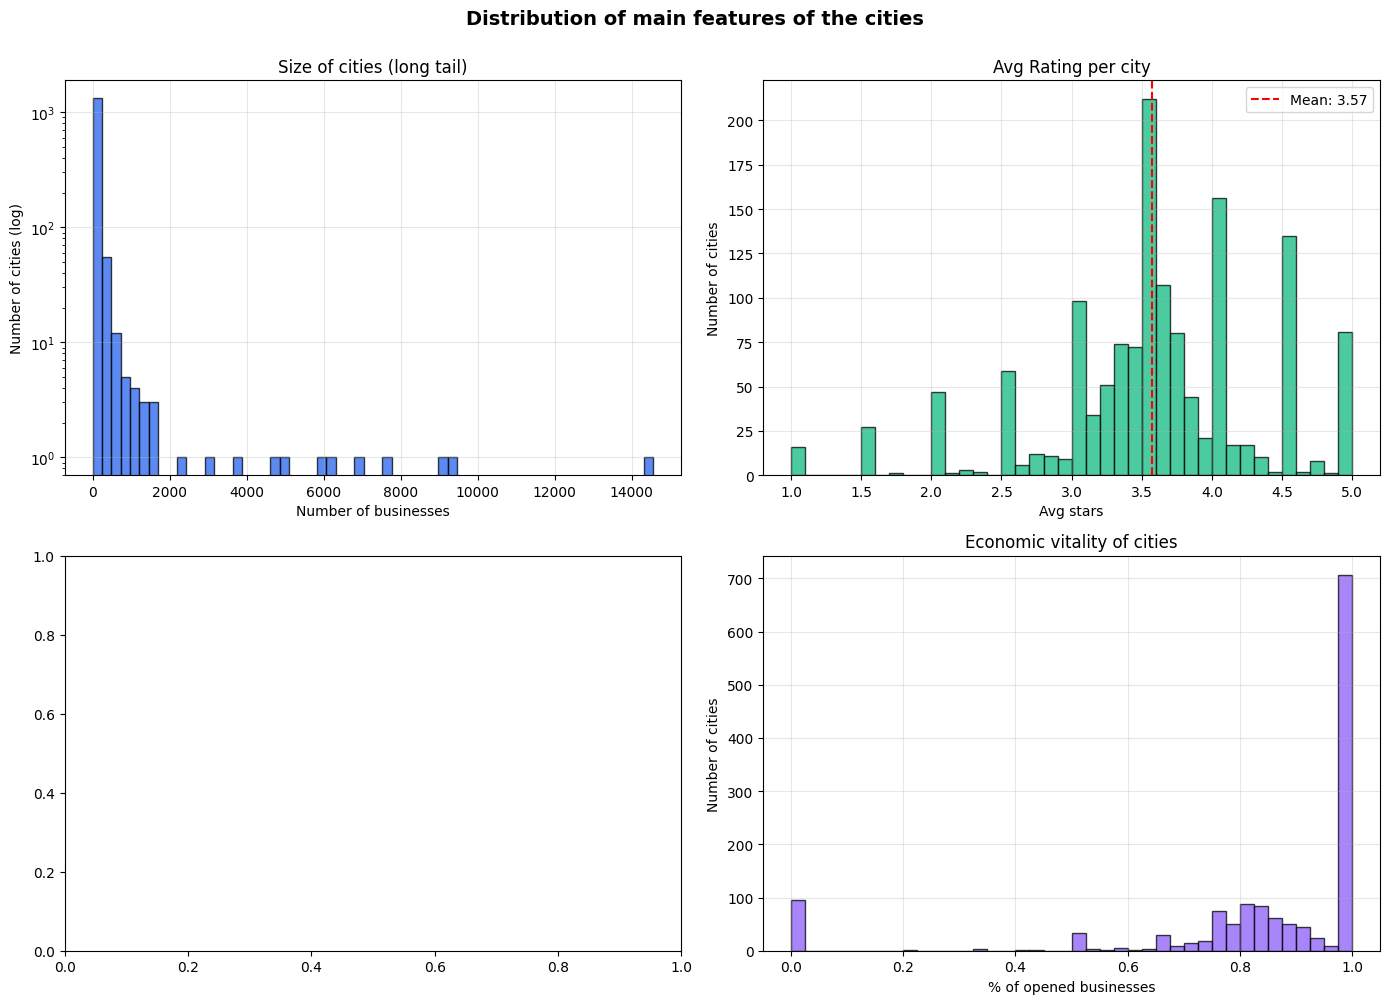

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# size of cities (long tail → log)
axes[0, 0].hist(city_features['n_businesses'], bins=60,
                color='#2563EB', edgecolor='black', alpha=0.75)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Number of businesses')
axes[0, 0].set_ylabel('Number of cities (log)')
axes[0, 0].set_title('Size of cities (long tail)')
axes[0, 0].grid(alpha=0.3)

# mean quality
axes[0, 1].hist(city_features['avg_stars'], bins=40,
                color='#10B981', edgecolor='black', alpha=0.75)
mean_stars = city_features['avg_stars'].mean()
axes[0, 1].axvline(mean_stars, color='red', linestyle='--',
                   label=f'Mean: {mean_stars:.2f}')
axes[0, 1].set_xlabel('Avg stars')
axes[0, 1].set_ylabel('Number of cities')
axes[0, 1].set_title('Avg Rating per city')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# % of opened businesses
axes[1, 1].hist(city_features['pct_open'], bins=40,
                color='#8B5CF6', edgecolor='black', alpha=0.75)
axes[1, 1].set_xlabel('% of opened businesses')
axes[1, 1].set_ylabel('Number of cities')
axes[1, 1].set_title('Economic vitality of cities')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Distribution of main features of the cities',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

The four distribution panels reveal why StandardScaler is mandatory before PCA. Business count and avg_checkins_biz follow extreme right-skewed distributions spanning orders of magnitude — a handful of large cities would otherwise dominate the principal components. Average rating concentrates between 3.5 and 4.5 with quantization peaks at round values (3.5, 4.0, 4.5, 5.0) caused by small cities with few businesses. The pct_open distribution shows a bimodal pattern: most cities are 80–100% open, but a distinct group near 0% exists, likely data quality issues rather than genuine ghost citie

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_num)

In [ ]:
print(f'Mean after scaling (~0): {X_scaled.mean():.6f}')
print(f'Std after scaling (~1):  {X_scaled.std():.6f}')

Mean after scaling (~0): -0.000000
Std after scaling (~1):  1.000000


In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

PCA(random_state=42)

In [ ]:
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_70 = np.argmax(cumvar >= 0.70) + 1
n_75 = np.argmax(cumvar >= 0.75) + 1
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

In [ ]:
print(f'Components for 70% variance: {n_70}')
print(f'Components for 75% variance: {n_75}')
print(f'Components for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'Total features:              {X_scaled.shape[1]}')


print(f'Reduction ratio (70%):       {1 - n_70/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (75%):       {1 - n_75/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (80%):       {1 - n_80/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (90%):       {1 - n_90/X_scaled.shape[1]:.1%} fewer dimensions')

Components for 70% variance: 24
Components for 75% variance: 28
Components for 80% variance: 31
Components for 90% variance: 41
Total features:              61
Reduction ratio (70%):       60.7% fewer dimensions
Reduction ratio (75%):       54.1% fewer dimensions
Reduction ratio (80%):       49.2% fewer dimensions
Reduction ratio (90%):       32.8% fewer dimensions


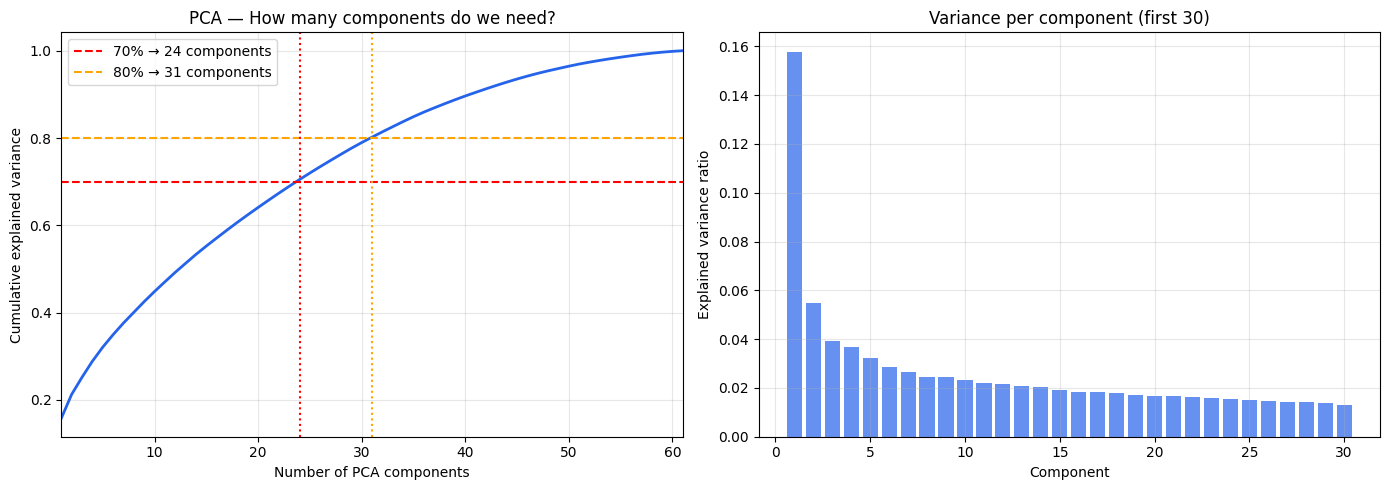


First component explains: 15.8%
Second component explains: 5.5%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
ax1.plot(range(1, len(cumvar)+1), cumvar, linewidth=2, color='#2563EB')
ax1.axhline(0.70, color='red',    linestyle='--', label=f'70% → {n_70} components')
ax1.axhline(0.80, color='orange', linestyle='--', label=f'80% → {n_80} components')
ax1.axvline(n_70, color='red',    linestyle=':')
ax1.axvline(n_80, color='orange', linestyle=':')
ax1.set_xlabel('Number of PCA components')
ax1.set_ylabel('Cumulative explained variance')
ax1.set_title('PCA — How many components do we need?')
ax1.legend()
ax1.set_xlim(1, min(150, X_scaled.shape[1]))
ax1.grid(alpha=0.3)

# Individual component variance (first 30)
ax2.bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='#2563EB', alpha=0.7)
ax2.set_xlabel('Component')
ax2.set_ylabel('Explained variance ratio')
ax2.set_title('Variance per component (first 30)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\nFirst component explains: {pca_full.explained_variance_ratio_[0]:.1%}')
print(f'Second component explains: {pca_full.explained_variance_ratio_[1]:.1%}')

gradual growth there are no visible elbows

In [ ]:
for n in [20, 30, 40, 50,70]:
    var = np.sum(pca_full.explained_variance_ratio_[:n])
    print(f'{n:4d} components → {var:.1%} variance')

  20 components → 64.1% variance
  30 components → 79.0% variance
  40 components → 89.6% variance
  50 components → 96.5% variance
  70 components → 100.0% variance


PCA reveals that the feature matrix exhibits moderate redundancy with a widely distributed variance structure. Approximately 75% of the variance is retained after 28 components, indicating that no small subset of features dominates the representation.


In [ ]:
comparison = pd.DataFrame({
    "Setting": ["Original", "PCA 70%", "PCA 75%", "PCA 80%","PCA 90%"],
    "Dimensions": [X_scaled.shape[1],n_70, n_75, n_80, n_90],
    "Variance Retained": [1.0, 0.70, 0.75, 0.80, 0.90]
})

comparison

,Setting,Dimensions,Variance Retained
0,Original,61,1.00
1,PCA 70%,24,0.70
2,PCA 75%,28,0.75
3,PCA 80%,31,0.80
4,PCA 90%,41,0.90


In [ ]:
# Reduce to 75%
pca = PCA(n_components=n_75, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (1416, 28)


For clustering (W7), selecting 28 components (75% variance) provides a reasonable trade-off between dimensionality reduction and information retention, while helping mitigate the curse of dimensionality in K-Means.

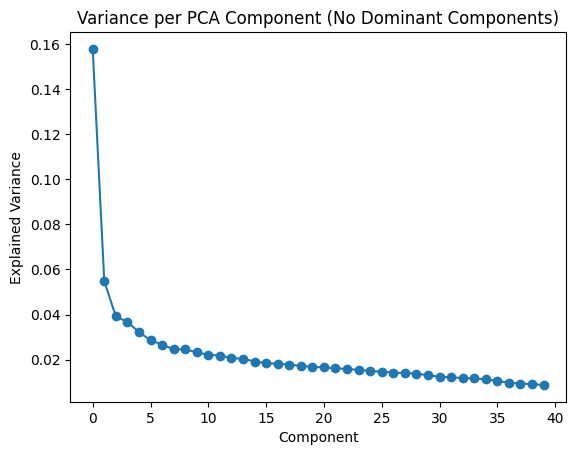

In [ ]:
explained = pca_full.explained_variance_ratio_

plt.figure()
plt.plot(explained[:40], marker='o')  # first 40 components
plt.xlabel("Component")
plt.ylabel("Explained Variance")
plt.title("Variance per PCA Component (No Dominant Components)")
plt.show()

The gradual decay of explained variance confirms that no single component dominates the feature space, reflecting the complex and multi-dimensional nature of city characteristics.

In [ ]:
feature_names = city_num.columns

In [ ]:
for i in range(0,10):

    loadings = pd.Series(
        pca.components_[i],
        index=feature_names
    )

    print(f'\nPC{i+1}')
    print(loadings.abs().sort_values(ascending=False).head(10))


PC1
city_pct_RestaurantsGoodForGroups    0.268020
city_pct_attire_casual               0.267287
city_pct_RestaurantsTakeOut          0.251003
city_pct_HasTV                       0.243960
personality__food_dining             0.237610
city_pct_Ambience__casual            0.220494
city_pct_GoodForKids                 0.210812
city_pct_GoodForMeal__dinner         0.209543
city_pct_OutdoorSeating              0.205613
city_pct_GoodForMeal__lunch          0.197951
dtype: float64

PC2
price_num                           0.302022
city_pct_attire_dressy              0.279442
city_pct_alcohol_none               0.275974
city_pct_alcohol_full_bar           0.265904
city_pct_Ambience__classy           0.232579
city_pct_BusinessParking__valet     0.232475
city_pct_Ambience__upscale          0.222255
city_pct_RestaurantsReservations    0.212785
personality__nightlife_social       0.193427
avg_reviews_per_biz                 0.171672
dtype: float64

PC3
city_pct_BikeParking                   0.2939

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_[:5],
    columns=city_num.columns,
    index=[f'PC{i+1}' for i in range(5)]
)

# top contributors PC1
loadings.loc['PC1'].abs().sort_values(ascending=False).head(10)

,PC1
city_pct_RestaurantsGoodForGroups,0.268020
city_pct_attire_casual,0.267287
city_pct_RestaurantsTakeOut,0.251003
city_pct_HasTV,0.243960
personality__food_dining,0.237610
city_pct_Ambience__casual,0.220494
city_pct_GoodForKids,0.210812
city_pct_GoodForMeal__dinner,0.209543
city_pct_OutdoorSeating,0.205613
city_pct_GoodForMeal__lunch,0.197951


 Cities high on PC1 have dense, accessible, family-and-group-oriented restaurant ecosystems.

In [ ]:
loadings.loc['PC2'].abs().sort_values(ascending=False).head(10)

,PC2
price_num,0.302022
city_pct_attire_dressy,0.279442
city_pct_alcohol_none,0.275974
city_pct_alcohol_full_bar,0.265904
city_pct_Ambience__classy,0.232579
city_pct_BusinessParking__valet,0.232475
city_pct_Ambience__upscale,0.222255
city_pct_RestaurantsReservations,0.212785
personality__nightlife_social,0.193427
avg_reviews_per_biz,0.171672


PC2 captures upscale and socially oriented dining environments characterized by higher prices, formal attire, reservations, valet parking, and nightlife-related restaurant culture.

In [ ]:
loadings.loc['PC3'].abs().sort_values(ascending=False).head(10)

,PC3
city_pct_BikeParking,0.293915
personality__beauty_wellness,0.292463
city_pct_WheelchairAccessible,0.290087
city_pct_attire_dressy,0.227227
city_pct_ByAppointmentOnly,0.223518
avg_stars,0.206254
city_pct_BusinessParking__lot,0.202074
city_pct_BusinessAcceptsCreditCards,0.192705
city_pct_GoodForMeal__brunch,0.190952
personality__shopping_retail,0.181712


PC3 represents wellness-oriented and service-accessible commercial environments characterized by accessibility infrastructure, professional services, shopping, and lifestyle-oriented amenities.

In [ ]:
loadings.loc['PC4'].abs().sort_values(ascending=False).head(10)

,PC4
city_pct_BusinessParking__valet,0.257147
avg_reviews_per_biz,0.252763
avg_checkins_biz,0.247079
city_pct_WheelchairAccessible,0.234427
city_pct_GoodForMeal__dinner,0.193376
city_pct_GoodForMeal__lunch,0.191883
city_pct_BusinessParking__validated,0.189611
city_pct_alcohol_none,0.189312
city_pct_Ambience__casual,0.188845
personality__beauty_wellness,0.184272


PC4 captures commercially active dining ecosystems with strong customer engagement, accessibility infrastructure, and high restaurant interaction intensity.

In [ ]:
loadings.loc['PC5'].abs().sort_values(ascending=False).head(10)

,PC5
city_pct_GoodForMeal__brunch,0.430770
city_pct_GoodForMeal__breakfast,0.398570
city_pct_attire_dressy,0.304152
city_pct_GoodForMeal__dessert,0.262461
city_pct_Ambience__upscale,0.257194
personality__nightlife_social,0.236356
noise_num,0.222101
city_pct_BusinessParking__valet,0.193670
city_pct_GoodForMeal__lunch,0.169540
city_pct_alcohol_full_bar,0.146016


PC5 captures brunch-oriented and socially active dining culture characterized by breakfast, dessert, upscale ambience, and nightlife-associated restaurant environments.

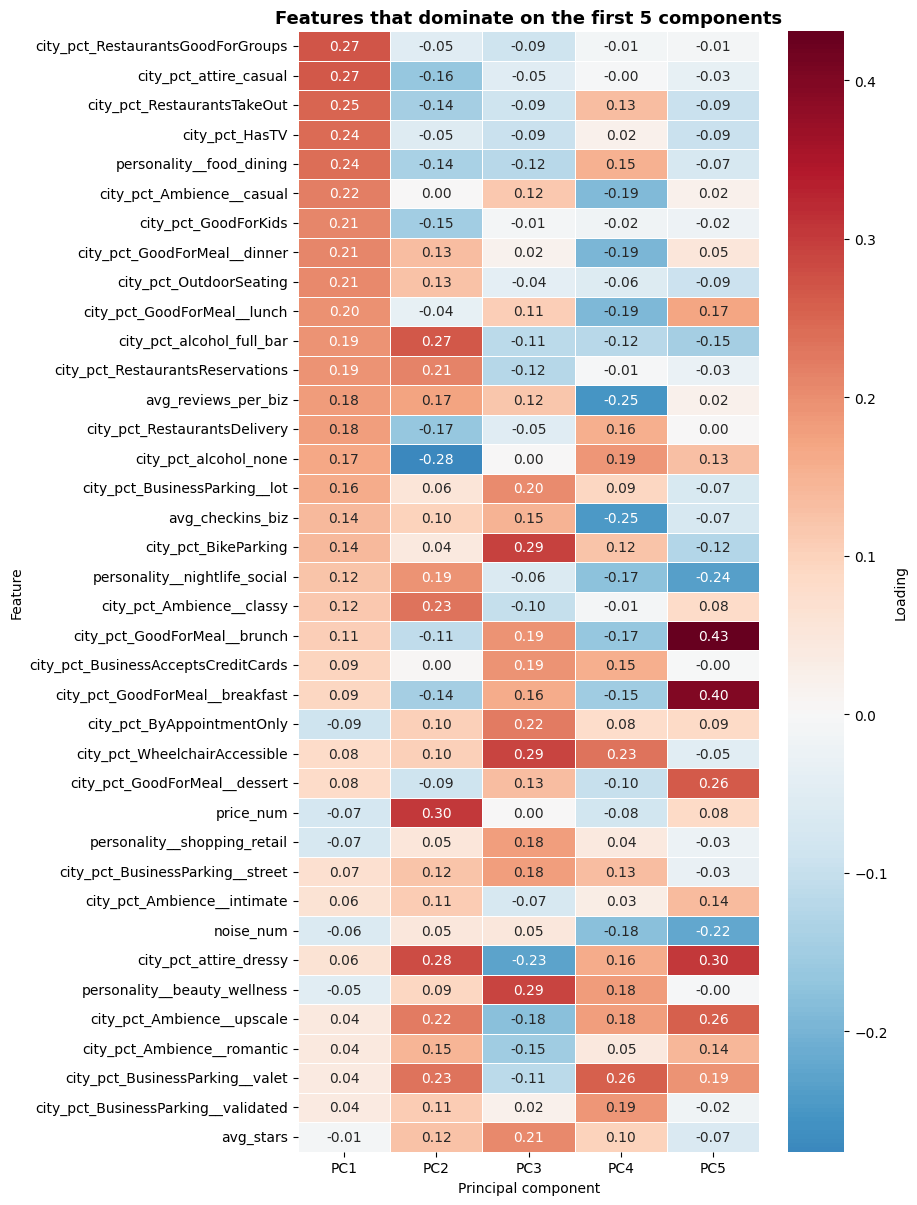

In [ ]:
# Top features that contribute to the first 5 principal components
n_pcs_show = 5
n_top_per_pc = 12

top_feats = set()
for i in range(n_pcs_show):
    idx = np.abs(pca_full.components_[i]).argsort()[::-1][:n_top_per_pc]
    top_feats.update(city_num.columns[idx])

top_feats = list(top_feats)
col_idx  = [city_num.columns.get_loc(f) for f in top_feats]

loadings_top = pd.DataFrame(
    pca_full.components_[:n_pcs_show, col_idx].T,
    index=top_feats,
    columns=[f'PC{i+1}' for i in range(n_pcs_show)]
)
# Order by magnitude on PC1
loadings_top = loadings_top.reindex(
    loadings_top['PC1'].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(9, max(8, len(top_feats)*0.32)))
sns.heatmap(loadings_top, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'}, linewidths=0.4)
plt.title('Features that dominate on the first 5 components',
          fontsize=13, fontweight='bold')
plt.xlabel('Principal component')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The first five principal components capture distinct urban-commercial lifestyles rather than simple business scale as mentioned before. For ex. PC2 and PC5 introduce more socially driven dimensions related to upscale dining, nightlife, brunch, and leisure-oriented restaurant culture, while PC3 captures wellness, accessibility, and lifestyle-service infrastructure. Because these dimensions capture complementary aspects of urban lifestyle instead of redundant variance, the dataset accumulates variance gradually across components, which explains why multiple PCs are needed to preserve the semantic structure used for clustering.

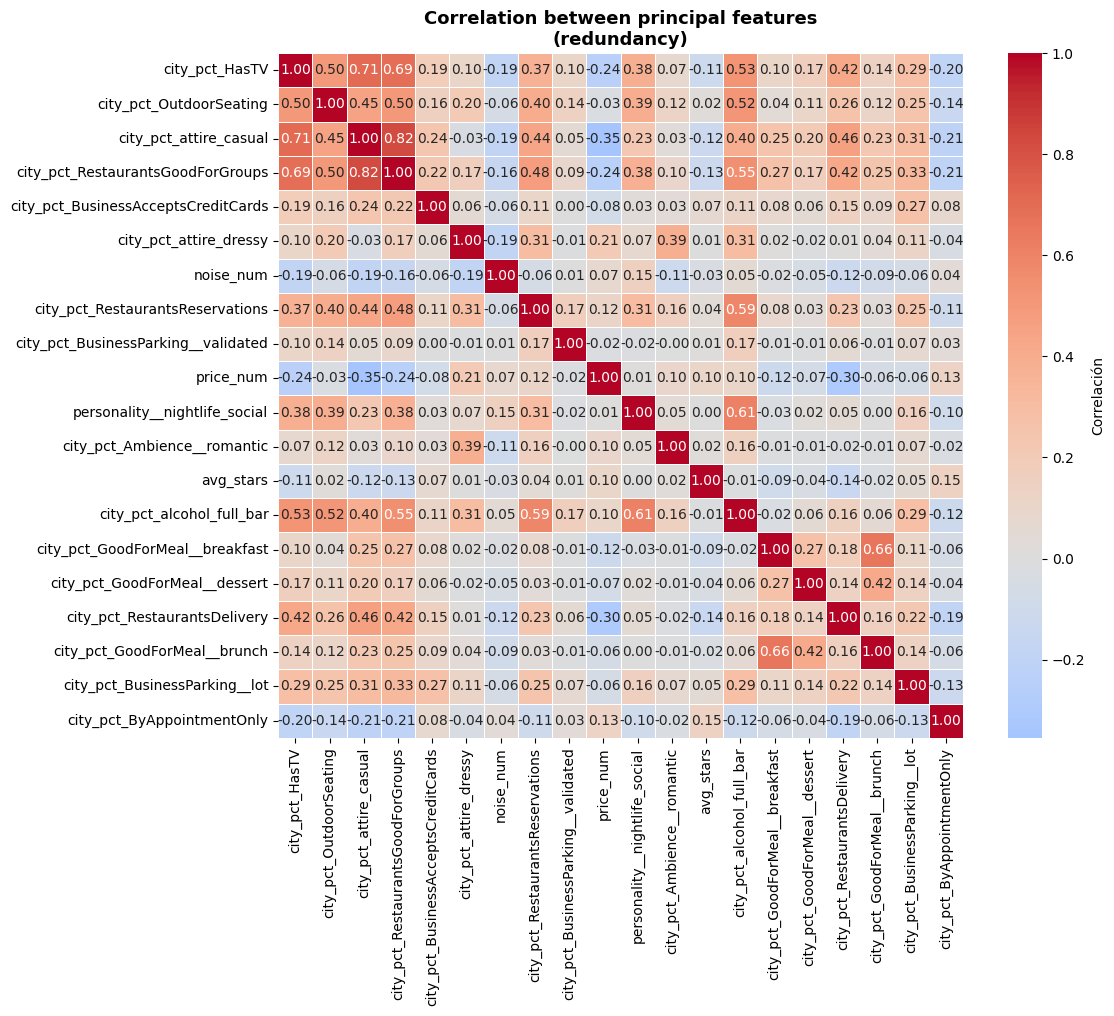

In [ ]:
# Correlation between keys
key_features = top_feats[:20]
key_features = [f for f in key_features if f in city_full.columns]

corr = city_full[key_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Correlation between principal features\n(redundancy)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap reveals clear block-level redundancy within specific feature groups. Casual dining variables such as group dining, casual attire, TV presence, and takeout services exhibit strong positive correlations, while brunch/breakfast activity and nightlife-related attributes also form smaller correlated clusters. In contrast, these thematic groups remain only weakly correlated with one another, producing a heterogeneous and multi-dimensional commercial structure. This explains the PCA behavior: local redundancy allows related features to compress into shared latent dimensions, but the relative independence between feature blocks causes variance to accumulate gradually across multiple principal components rather than collapsing into only a few dominant axes.

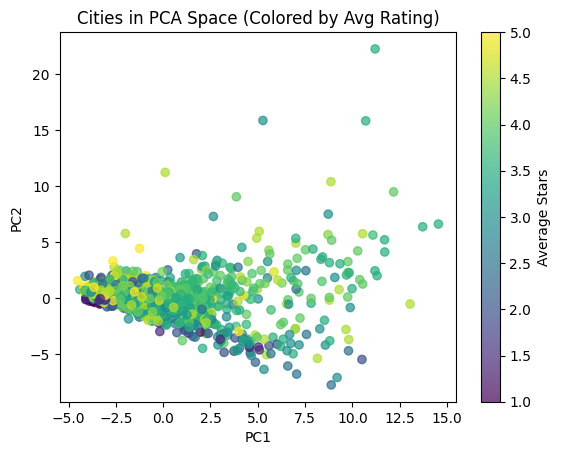

In [ ]:
# 2D projection
pca_2 = PCA(n_components=4, random_state=42)
X_2d = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1],
            c=city_features['avg_stars'],
            alpha=0.7)

plt.colorbar(label="Average Stars")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cities in PCA Space (Colored by Avg Rating)")
plt.show()

The PCA projection shows that cities are not primarily separated by average rating, since similar rating values appear across multiple regions of the embedding space. Instead, the first principal components capture broader urban-commercial lifestyles such as casual dining intensity, social activity, nightlife, and accessibility patterns. Most cities concentrate near the center, indicating shared mainstream commercial characteristics, while a smaller set of cities extends toward more extreme PC1 and PC2 values, reflecting more specialized or distinctive urban-commercial profiles.

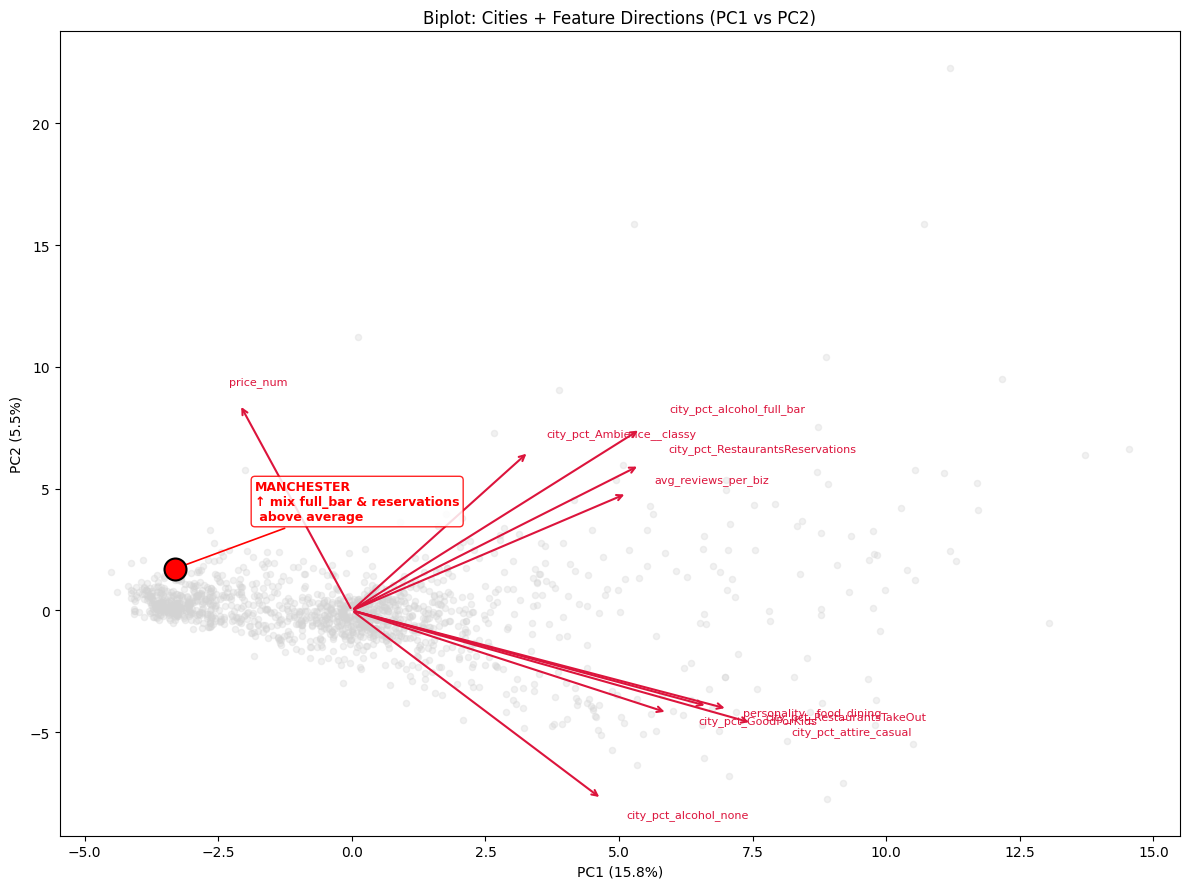

In [ ]:
# Biplot PC1 vs PC2
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=20, color='lightgray')

# Arrows for top 10 features por PC1+PC2
top_features_idx = np.argsort(
    np.abs(pca_full.components_[0]) + np.abs(pca_full.components_[1])
)[-10:]

scale = 28
for idx in top_features_idx:
    ax.annotate('', xy=(pca_full.components_[0, idx]*scale,
                        pca_full.components_[1, idx]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
    ax.text(pca_full.components_[0, idx]*scale*1.1,
            pca_full.components_[1, idx]*scale*1.1,
            city_num.columns[idx], fontsize=8, color='crimson')

ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
ax.set_title('Biplot: Cities + Feature Directions (PC1 vs PC2)')

example_city = 'MANCHESTER'
mask = city_full['city'].values == example_city
city_x = X_2d[mask, 0][0]
city_y = X_2d[mask, 1][0]

# Punto rojo destacado
plt.scatter(city_x, city_y, c='red', s=250, zorder=10,
            edgecolor='black', linewidth=1.5)

# Anotación con interpretación
plt.annotate(
    f'{example_city}\n↑ mix full_bar & reservations\n above average',
    xy=(city_x, city_y),
    xytext=(city_x + 1.5, city_y + 2),
    fontsize=9,
    color='red',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor='red', alpha=0.85)
)
plt.tight_layout()
plt.show()

The biplot superimposes feature loading vectors onto the city scatter, revealing two structurally opposed directions in the PC1–PC2 space. Quality signals (avg_stars, pct_5stars) point upper-left, indicating that highly-rated cities score negatively on PC1 and positively on PC2 — they are less casual and food-dense, but more quality-polarized. In contrast, casual dining features (RestaurantsGoodForGroups, RestaurantsTakeOut, food_dining, attire_casual) point strongly right along PC1, with a slight downward tilt, meaning they oppose the quality axis. The alcohol_none and alcohol_full_bar vectors point in nearly opposite directions on PC2, cleanly separating family-oriented cities (no alcohol) from bar-culture cities (full bar + reservations). Cities in the dense central mass are commercial generalists; outliers along each arrow direction are cities whose commercial DNA is dominated by that feature cluster.

Philadelphia (red dot) scores modestly positive on both PC1 and PC2, placing it near the intersection of the casual dining and bar-reservation axes. This reflects its diverse commercial ecosystem: it has above-average proportions of full_bar and reservation-based restaurants, but also significant casual dining presence, which is why it does not sit at the extreme of either arrow. Cities at the tip of the full_bar or avg_stars vectors would be smaller, more specialized cities where one attribute dominates the entire commercial mix.

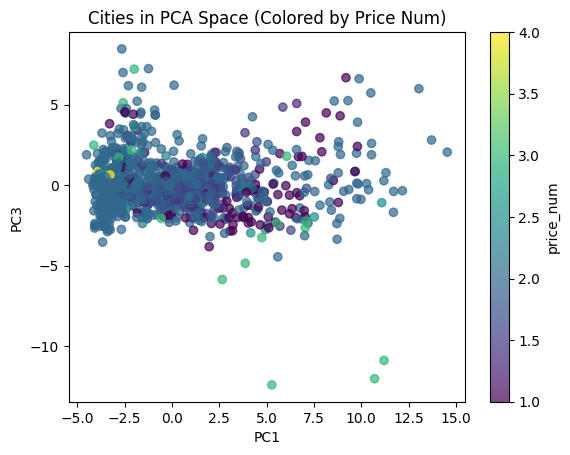

In [ ]:
#PC1 vs PC3 coloreado por price_num
plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,2],
            c=city_features['price_num'],
            alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("Cities in PCA Space (Colored by Price Num)")
plt.colorbar(label="price_num")

This projection colored by price level shows that restaurant pricing is moderately associated with the latent urban-commercial structure, but does not dominate the embedding space. Lower-priced cities appear more concentrated in regions with higher PC1 values, while higher-priced cities are more dispersed across the space, suggesting that pricing interacts with multiple lifestyle dimensions rather than defining a single urban archetype. This indicates that commercial identity is influenced not only by economic level, but also by dining style, social activity, and accessibility-related behaviors captured by the principal components.

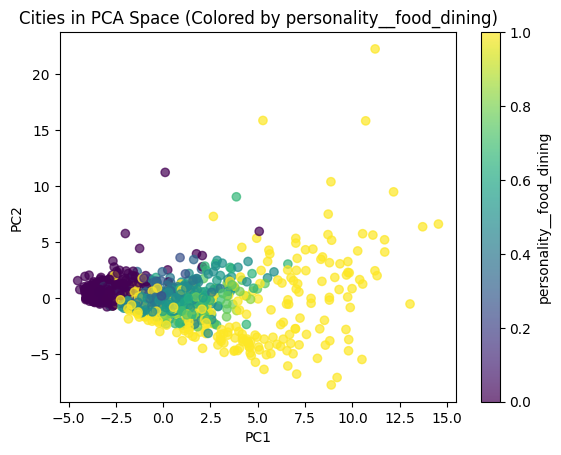

In [ ]:
plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1],
            c=city_features['personality__food_dining'],
            alpha=0.7)

plt.colorbar(label="personality__food_dining")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cities in PCA Space (Colored by personality__food_dining)")
plt.show()

This graph shows a clear gradient along PC1, confirming that the first principal component strongly captures food-oriented urban identity. Cities with higher food-and-dining personality scores are concentrated toward larger positive PC1 values, while lower-scoring cities cluster near the negative side of the axis. This reinforces the interpretation of PC1 as a mainstream dining and restaurant-culture dimension, indicating that food-related lifestyle behavior is one of the dominant structural patterns in the urban-commercial embedding space.

In [ ]:
# order city by most n_users
city_featuresord = city_features.sort_values(by='city_pct_RestaurantsGoodForGroups', ascending=False)

In [ ]:
city_featuresord.head(8)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,personality__pets,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
12,Alloway,2,3.75,3.75,0.353553,18,9.0,1.0,5.0,0.0,...,0.0,3.833333,1.382666,18,18,0.444444,0.111111,29.0,14.5,28.0
1411,wilmington,1,4.00,4.00,0.000000,61,61.0,1.0,6.0,0.0,...,0.0,4.161290,1.217274,62,61,0.564516,0.064516,48.0,48.0,48.0
634,Mango,1,3.00,3.00,0.000000,40,40.0,0.0,4.0,0.0,...,0.0,3.121951,1.584221,41,40,0.292683,0.243902,34.0,34.0,34.0
1344,Woodson Terrace,1,3.50,3.50,0.000000,63,63.0,0.0,3.0,0.0,...,0.0,3.539683,1.522153,63,63,0.412698,0.158730,185.0,185.0,185.0
1342,Woodbury Hts.,1,1.50,1.50,0.000000,10,10.0,1.0,3.0,0.0,...,0.0,1.545455,1.213560,11,10,0.000000,0.818182,27.0,27.0,27.0
707,"Mount Holly,",1,3.50,3.50,0.000000,26,26.0,1.0,2.0,0.0,...,0.0,3.615385,1.444352,26,26,0.384615,0.115385,19.0,19.0,19.0
712,Mount Royal,2,4.00,4.00,0.707107,48,24.0,1.0,4.0,0.0,...,0.0,4.142857,1.258306,49,47,0.571429,0.081633,68.0,34.0,44.0
36,BOISE,1,2.50,2.50,0.000000,5,5.0,0.0,2.0,0.0,...,0.0,2.400000,1.673320,5,5,0.200000,0.400000,12.0,12.0,12.0


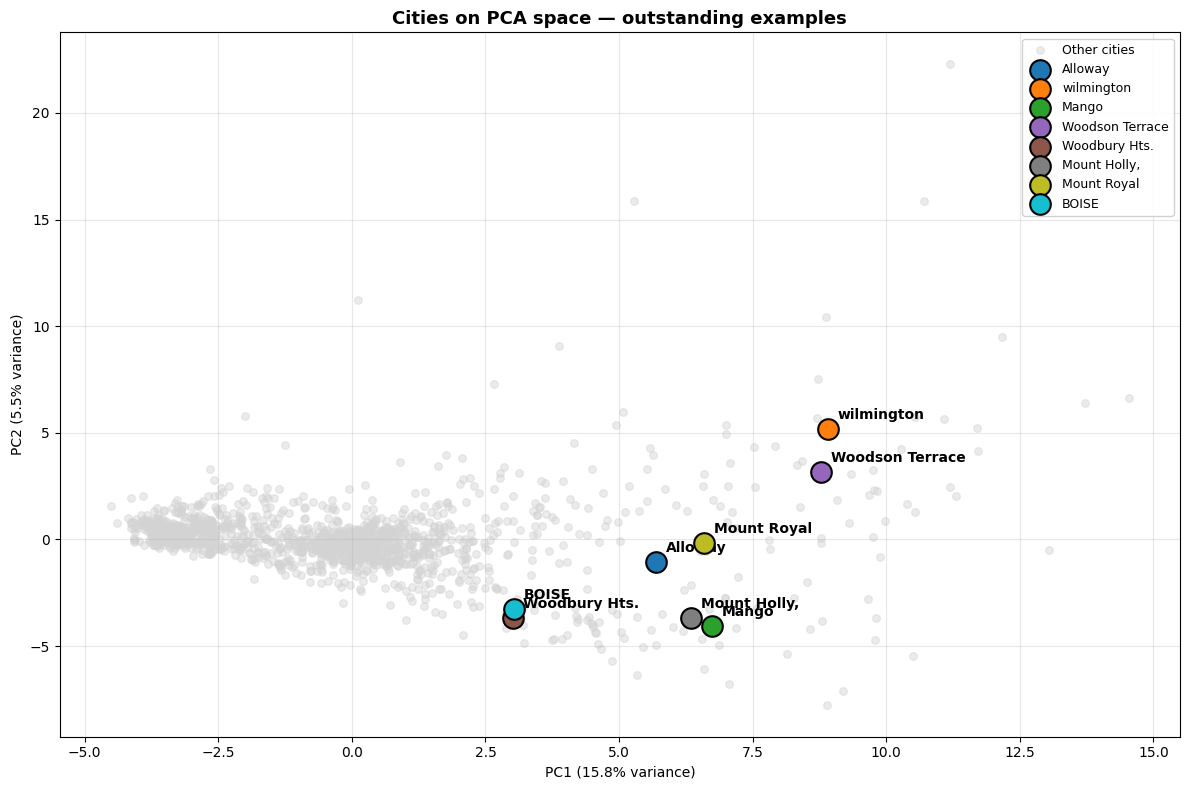

In [ ]:
# 2D Proyection with most emblematic cities highlighted
plt.figure(figsize=(12, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', alpha=0.45, s=30,
            label='Other cities')

cities_to_highlight = ['Alloway', 'wilmington', 'Mango', 'Woodson Terrace',
                       'Woodbury Hts.', 'Mount Holly,', 'Mount Royal', 'BOISE']
colors = plt.cm.tab10(np.linspace(0, 1, len(cities_to_highlight)))

for city, color in zip(cities_to_highlight, colors):
    mask = city_features['city'].values == city
    if mask.any():
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], s=220,
                    edgecolor='black', linewidth=1.5, label=city, zorder=5)
        plt.annotate(city, (X_2d[mask, 0][0], X_2d[mask, 1][0]),
                     xytext=(7, 7), textcoords='offset points',
                     fontsize=10, fontweight='bold')

plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Cities on PCA space — outstanding examples',
          fontsize=13, fontweight='bold')
plt.legend(loc='best', framealpha=0.9, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The PCA projection highlights several cities with distinctive urban-commercial profiles relative to the broader distribution of cities concentrated near the center of the embedding space. For example, Wilmington and Woodson Terrace appear with high positive PC2 values, suggesting stronger upscale, nightlife, or socially active commercial characteristics. In contrast, cities such as Mango and Mount Holly are positioned lower on PC2, indicating more suburban or less engagement-oriented commercial environments despite relatively high PC1 values. Boise and Woodbury Hts. occupy intermediate positions, reflecting differentiated but less extreme commercial identities. Overall, the dispersion of these highlighted cities illustrates how PCA separates cities according to multiple lifestyle and dining dimensions rather than simple business quantity alone.

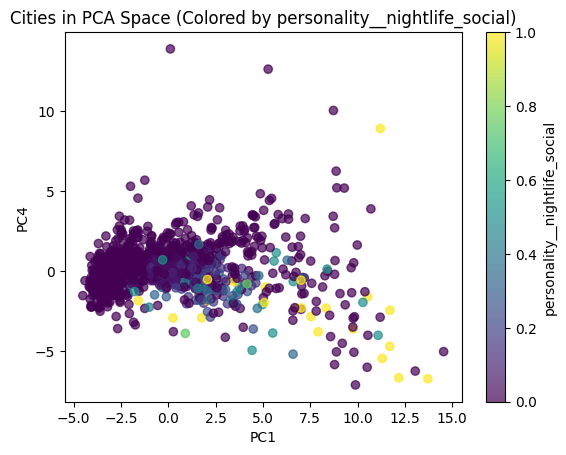

In [ ]:
# 2D projection
plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,3],
            c=city_features['personality__nightlife_social'],
            alpha=0.7)

plt.colorbar(label="personality__nightlife_social")
plt.xlabel("PC1")
plt.ylabel("PC4")
plt.title("Cities in PCA Space (Colored by personality__nightlife_social)")
plt.show()

The PCA projection colored by `personality__nightlife_social` shows that nightlife-oriented cities tend to concentrate toward higher PC1 values and lower PC4 values, suggesting an association between socially active nightlife environments and more specialized dining and leisure-oriented commercial profiles. In contrast, cities with low nightlife-social scores remain densely concentrated near the center-left region of the embedding space, reflecting more mainstream or less socially active urban-commercial ecosystems. This pattern indicates that nightlife behavior contributes to the differentiation of cities within the latent commercial structure extracted by PCA.


In [ ]:
# Para cada PC, las 5 ciudades más altas y más bajas
pca_df_sorted = pca_df.copy()
for pc in ['PC1', 'PC2', 'PC3', 'PC4']:
    top5 = pca_df_sorted.nlargest(5, pc)[['city', pc]]
    bot5 = pca_df_sorted.nsmallest(5, pc)[['city', pc]]
    print(f"\n{pc} extremes:")
    print(pd.concat([top5, bot5]))


PC1 extremes:
                         city        PC1
1169           Tarpon springs  14.497206
973                  ST LOUIS  13.752831
129                  Bucktown  12.952707
205   Clearwater/ Countryside  12.115794
1034                 Sherwood  11.764120
1222            UPPR BLCK EDY  -4.591494
332              Erdenheim Pa  -4.396349
541               Kings Beach  -4.303179
1025                  Secane   -4.257991
1074                  Sparks,  -4.243665

PC2 extremes:
                 city        PC2
440       Gulph Mills  15.975493
882        Pine Forge  11.624636
109        Brentwood   11.413600
924   Redington Shore  10.138472
90               Blvd   8.997807
147    Carney's Point  -7.932133
847     Peerless Park  -6.347641
1120          St.Rose  -6.338075
38            BRANDON  -6.290697
135        CLEARWATER  -6.282689

PC3 extremes:
                            city        PC3
1263                   Wanamaker   6.184654
1171                    Telford    5.422244
1053     

In [ ]:
pca_df.shape

(1416, 29)

In [ ]:
pca_df = pd.DataFrame(
    X_reduced,
    columns=[f'PC{i+1}' for i in range(X_reduced.shape[1])]
)

#keep city identifier
if city_ids is not None:
    pca_df.insert(0, 'city', city_ids.values)

pca_df.to_parquet("city_features_pca_new.parquet", index=False)

In [ ]:
import joblib

joblib.dump(pca, "pca_model_new.pkl")
joblib.dump(scaler, "scaler_new.pkl")

['scaler_new.pkl']